In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

In [2]:
stack_df = pd.read_csv('../../Feature Engineering/resources/stack_overflowcsv.csv')

In [3]:
stack_df.head()

,SurveyDate,FormalEducation,ConvertedSalary,Hobby,Country,StackOverflowJobsRecommend,VersionControl,Age,Years Experience,Gender,RawSalary
0,2/28/18 20:20,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,Yes,South Africa,NaN,Git,21,13,Male,NaN
1,6/28/18 13:26,Bachelor's degree (BA. BS. B.Eng.. etc.),70841.0,Yes,Sweeden,7.0,Git;Subversion,38,9,Male,"70,841.00"
2,6/6/18 3:37,Bachelor's degree (BA. BS. B.Eng.. etc.),NaN,No,Sweeden,8.0,Git,45,11,NaN,NaN
3,5/9/18 1:06,Some college/university study without earning ...,21426.0,Yes,Sweeden,NaN,Zip file back-ups,46,12,Male,"21,426.00"
4,4/12/18 22:41,Bachelor's degree (BA. BS. B.Eng.. etc.),41671.0,Yes,UK,8.0,Git,39,7,Male,"£41,671.00"


In [4]:
stack_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   SurveyDate                  999 non-null    str    
 1   FormalEducation             999 non-null    str    
 2   ConvertedSalary             665 non-null    float64
 3   Hobby                       999 non-null    str    
 4   Country                     999 non-null    str    
 5   StackOverflowJobsRecommend  487 non-null    float64
 6   VersionControl              999 non-null    str    
 7   Age                         999 non-null    int64  
 8   Years Experience            999 non-null    int64  
 9   Gender                      693 non-null    str    
 10  RawSalary                   665 non-null    str    
dtypes: float64(2), int64(2), str(7)
memory usage: 173.4 KB


In [6]:
stack_df.dtypes

SurveyDate                        str
FormalEducation                   str
ConvertedSalary               float64
Hobby                             str
Country                           str
StackOverflowJobsRecommend    float64
VersionControl                    str
Age                             int64
Years Experience                int64
Gender                            str
RawSalary                         str
dtype: object

In [7]:
stack_df.isna().sum()

SurveyDate                      0
FormalEducation                 0
ConvertedSalary               334
Hobby                           0
Country                         0
StackOverflowJobsRecommend    512
VersionControl                  0
Age                             0
Years Experience                0
Gender                        306
RawSalary                     334
dtype: int64

In [15]:
stack_df.nunique()

SurveyDate                    997
FormalEducation                 9
ConvertedSalary               446
Hobby                           2
Country                        10
StackOverflowJobsRecommend     11
VersionControl                 39
Age                            57
Years Experience               25
Gender                          8
RawSalary                     515
dtype: int64

<Axes: >

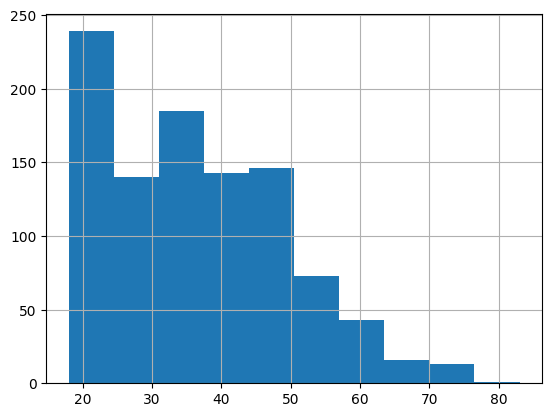

In [9]:
stack_df['Age'].hist()

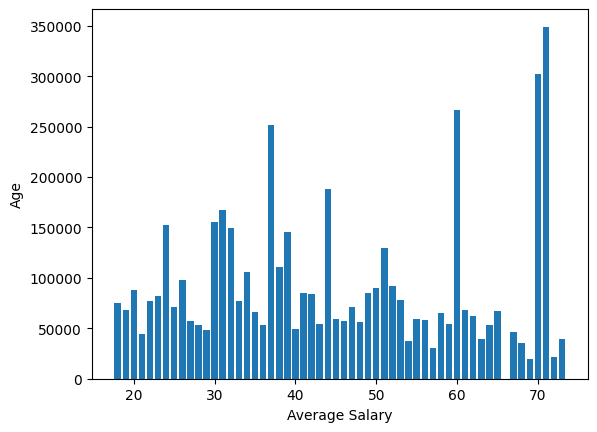

In [19]:
age_salary = stack_df.groupby('Age')['ConvertedSalary'].mean()

plt.bar(age_salary.index, age_salary.values)
plt.xlabel("Average Salary")
plt.ylabel("Age")
plt.show()

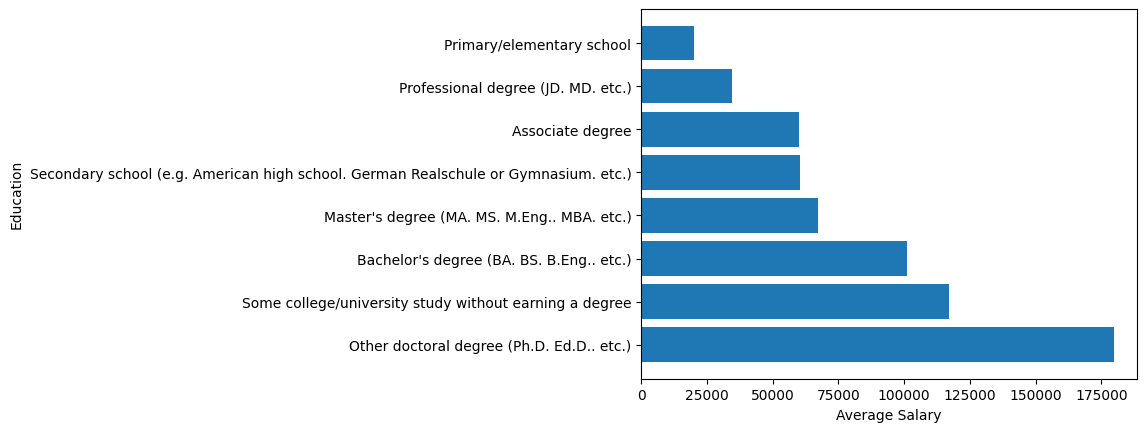

In [25]:
formal_edu = stack_df.groupby('FormalEducation')['ConvertedSalary'].mean().sort_values(ascending=False)

plt.barh(formal_edu.index, formal_edu.values)
plt.xlabel("Average Salary")
plt.ylabel("Education")
plt.show()

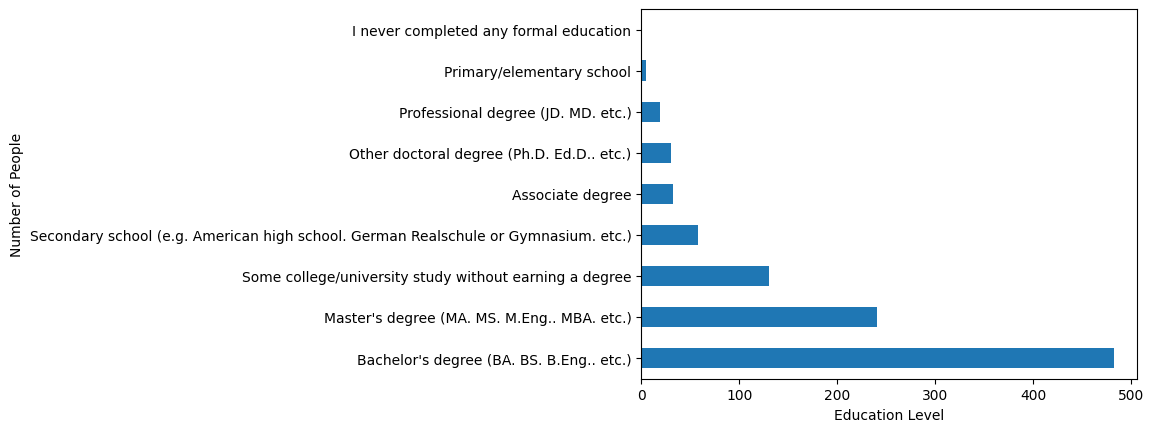

In [49]:
stack_df['FormalEducation'].value_counts().plot(kind='barh')
plt.xlabel("Education Level")
plt.ylabel("Number of People")
plt.show()

<Axes: xlabel='Age', ylabel='FormalEducation'>

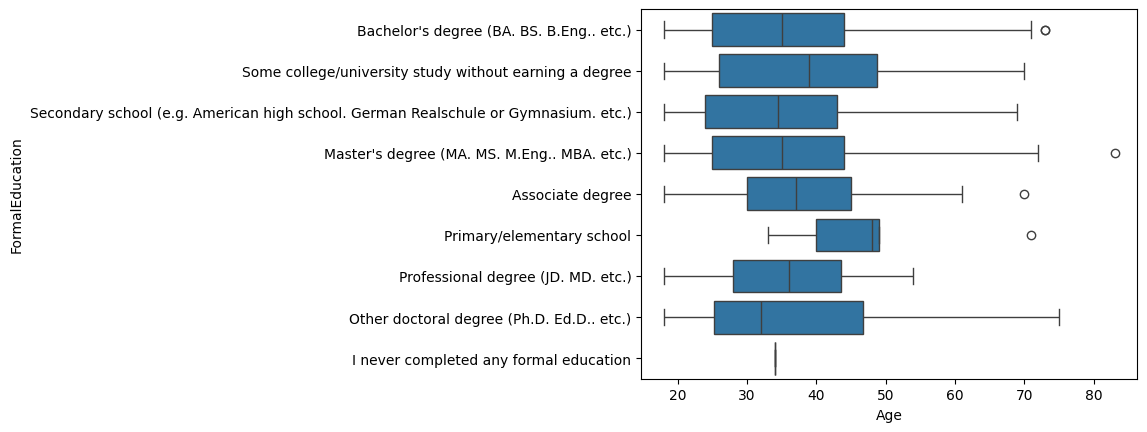

In [61]:
sns.boxplot(data=stack_df,x='Age',y='FormalEducation')

KeyError: 'smoker'

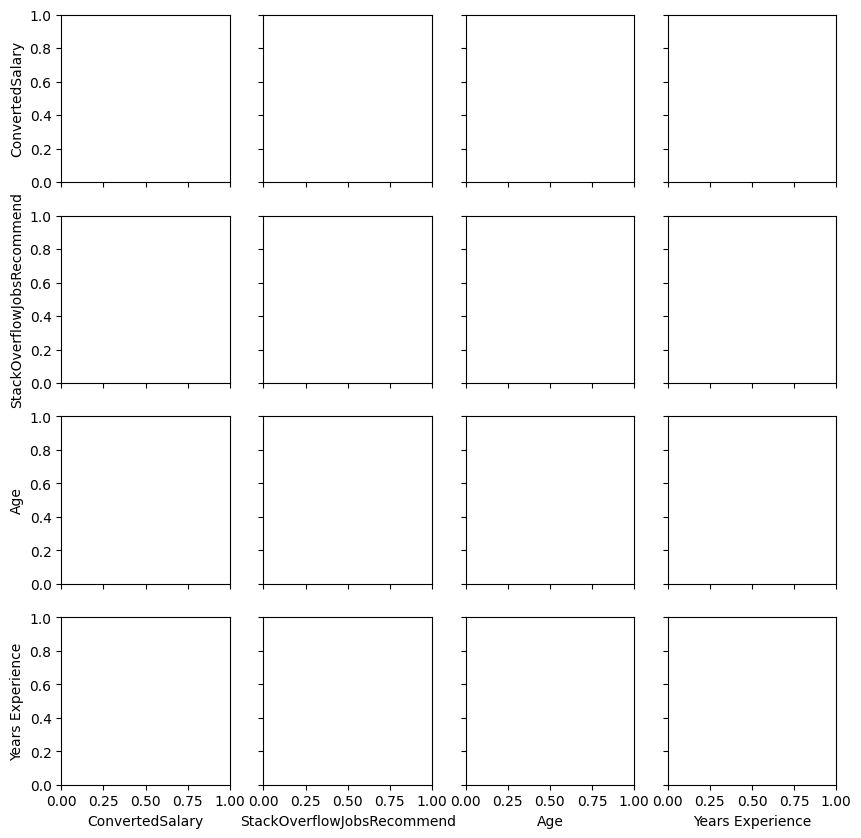

In [63]:
sns.pairplot(stack_df,hue="smoker", palette="coolwarm")